# Task 4: Forecasting Access and Usage, 2025-2027

Ethiopia Financial Inclusion Forecasting — Selam Analytics

Targets: **Account Ownership Rate** (`ACC_OWNERSHIP`, Access) and **Digital
Payment Adoption Rate** (`USG_DIGITAL_PAYMENT`, Usage). We deliberately use two
different methods for the two targets, because they have very different data
density: Account Ownership has 4 Findex points (2014-2024) and can support a
real trend regression; Digital Payment Adoption has **exactly one** point
(35%, 2024) and cannot — for that target we build transparent, judgment-based
scenarios instead of pretending to fit a trend that doesn't exist.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns

from src.data_loader import load_unified_data, get_observations, get_events, get_impact_links, get_targets

sns.set_theme(style="whitegrid", palette="deep")
FIG_DIR = Path.cwd().parent / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR = Path.cwd().parent / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

df = load_unified_data()
obs = get_observations(df)
events = get_events(df)
impacts = get_impact_links(df)
targets = get_targets(df)

## 1. Re-establish the Task 3 event-effect model

Same delayed-ramp functional form as Task 3 (`03_impact_modeling.ipynb`), so
the event-augmented forecast is directly consistent with the validated
impact model rather than a separately invented number.

In [2]:
event_impacts = impacts.merge(
    events, left_on="parent_id", right_on="record_id", suffixes=("_impact", "_event")
).rename(columns={
    "indicator_event": "event_name", "observation_date_event": "event_date",
    "related_indicator_impact": "related_indicator", "impact_direction_impact": "impact_direction",
    "impact_magnitude_impact": "impact_magnitude", "impact_estimate_impact": "impact_estimate",
    "lag_months_impact": "lag_months",
})

RAMP_MONTHS = 12.0
MAGNITUDE_DEFAULT_PP = {"high": 8.0, "medium": 4.0, "low": 1.5, "negligible": 0.3}
MAGNITUDE_DEFAULT_PCT = {"high": 25.0, "medium": 10.0, "low": 3.0, "negligible": 0.5}
PP_VALUE_TYPES = {"percentage", "gap_pp", "rate"}

indicator_meta = obs.groupby("indicator_code").agg(value_type=("value_type", "first"))


def default_magnitude(indicator_code, magnitude):
    value_type = indicator_meta.loc[indicator_code, "value_type"] if indicator_code in indicator_meta.index else "count"
    table = MAGNITUDE_DEFAULT_PP if value_type in PP_VALUE_TYPES else MAGNITUDE_DEFAULT_PCT
    return table.get(magnitude, 0.0)


def signed_full_effect(row):
    est = row["impact_estimate"]
    magnitude_val = est if pd.notna(est) else default_magnitude(row["related_indicator"], row["impact_magnitude"])
    if row["impact_direction"] == "decrease":
        return -magnitude_val
    if row["impact_direction"] in ("stabilize", "mixed"):
        return 0.0
    return magnitude_val


event_impacts["full_effect"] = event_impacts.apply(signed_full_effect, axis=1)


def ramp_fraction(elapsed_months, lag_months, ramp_months=RAMP_MONTHS):
    if elapsed_months <= lag_months:
        return 0.0
    return min(1.0, (elapsed_months - lag_months) / ramp_months)


def effect_at(event_date, lag_months, full_effect, target_date):
    elapsed = (target_date - event_date).days / 30.44
    return full_effect * ramp_fraction(elapsed, lag_months if pd.notna(lag_months) else 0.0)


def indicator_effect_at(indicator_code, target_date):
    rows = event_impacts[event_impacts.related_indicator == indicator_code]
    return sum(effect_at(r.event_date, r.lag_months, r.full_effect, target_date) for _, r in rows.iterrows())


print("Event-effect model re-established.")

Event-effect model re-established.


## 2. ACCESS forecast: Account Ownership Rate

In [3]:
acc = obs[(obs.indicator_code == "ACC_OWNERSHIP") & (obs.gender == "all") & (obs.location == "national")].sort_values("observation_date")
acc_years = acc.observation_date.dt.year.values.astype(float)
acc_values = acc.value_numeric.values

print(acc[["observation_date", "value_numeric"]])

  observation_date  value_numeric
0       2014-12-31           22.0
1       2017-12-31           35.0
2       2021-12-31           46.0
5       2024-11-29           49.0


### 2a. Statistical trend (OLS on all 4 Findex points, with prediction interval)

In [4]:
X = sm.add_constant(acc_years)
ols_model = sm.OLS(acc_values, X).fit()
print(ols_model.summary())

future_years = np.array([2025, 2026, 2027], dtype=float)
X_future = sm.add_constant(future_years, has_constant="add")
pred = ols_model.get_prediction(X_future)
pred_summary = pred.summary_frame(alpha=0.20)  # 80% interval, honest given n=4
pred_summary.index = future_years.astype(int)
pred_summary

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.944
Model:                            OLS   Adj. R-squared:                  0.917
Method:                 Least Squares   F-statistic:                     33.98
Date:                Tue, 28 Jul 2026   Prob (F-statistic):             0.0282
Time:                        12:14:42   Log-Likelihood:                -9.3423
No. Observations:                   4   AIC:                             22.68
Df Residuals:                       2   BIC:                             21.46
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -5427.2241    937.622     -5.788      0.0

C:\Python312\Lib\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 4 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
2025,54.241379,3.300171,48.018518,60.464241,45.120025,63.362733
2026,56.948276,3.700646,49.970270,63.926281,47.295936,66.600615
2027,59.655172,4.114580,51.896645,67.413699,49.424345,69.886000


**Caveat visible in the regression itself:** with n=4 and a decelerating trend
(growth per period: +13pp, +11pp, +3pp), a single linear slope fit across all
four points is not a great description of the process — it averages a fast
early period with a much slower recent one. We therefore treat this full-period
OLS as an **optimistic-leaning statistical anchor**, and build a second,
recent-trend baseline below that better reflects the current deceleration.

### 2b. Recent-trend baseline (2021→2024 slope only)

In [5]:
recent_slope = (49 - 46) / (2024 - 2021)  # pp per year, ~1.0
print(f"Recent (2021-2024) trend: {recent_slope:.2f} pp/year")

recent_trend_forecast = {
    2025: 49 + recent_slope * 1,
    2026: 49 + recent_slope * 2,
    2027: 49 + recent_slope * 3,
}
recent_trend_forecast

Recent (2021-2024) trend: 1.00 pp/year


{2025: 50.0, 2026: 51.0, 2027: 52.0}

### 2c. Event-augmented forecast

Recent-trend baseline **plus** the incremental modeled event effect that
accumulates *after* the 2024 survey date (avoiding double-counting effects
already embedded in the observed 49%). Forward-looking events include M-Pesa/
EthSwitch interoperability (Oct 2025), the Fayda banking mandate (Sep 2025,
`mixed`, contributes 0), EthioPay's indirect Access effect (Dec 2025), and the
continued ramp of NFIS-II / Fayda rollout / M-Pesa entry that were still
maturing as of the 2024 survey.

In [6]:
baseline_date = pd.Timestamp("2024-11-29")
baseline_effect = indicator_effect_at("ACC_OWNERSHIP", baseline_date)

event_augmented_forecast = {}
for year in [2025, 2026, 2027]:
    target_date = pd.Timestamp(f"{year}-12-31")
    incremental_effect = indicator_effect_at("ACC_OWNERSHIP", target_date) - baseline_effect
    event_augmented_forecast[year] = recent_trend_forecast[year] + incremental_effect

event_augmented_forecast

{2025: 53.943166885676746, 2026: 56.93856767411301, 2027: 60.07939115199299}

### 2d. Scenarios: optimistic / base / pessimistic

- **Base** = event-augmented forecast above (100% of modeled event effects, recent trend).
- **Optimistic** = full-period OLS trend (faster growth) + 130% of modeled event effects
  (assumes EthioPay/interoperability land on schedule and outperform).
- **Pessimistic** = recent trend only, with just 40% of modeled event effects
  (assumes continued FX/price-driven headwinds and rollout delays — see IMP_0013, IMP_0021, IMP_0022).

In [7]:
scenarios_acc = {"year": [2025, 2026, 2027]}

optimistic, base, pessimistic = [], [], []
for year in [2025, 2026, 2027]:
    target_date = pd.Timestamp(f"{year}-12-31")
    incr = indicator_effect_at("ACC_OWNERSHIP", target_date) - baseline_effect
    ols_val = pred_summary.loc[year, "mean"]

    optimistic.append(ols_val + 1.3 * incr)
    base.append(recent_trend_forecast[year] + incr)
    pessimistic.append(recent_trend_forecast[year] + 0.4 * incr)

scenarios_acc["optimistic"] = optimistic
scenarios_acc["base"] = base
scenarios_acc["pessimistic"] = pessimistic
scenarios_acc_df = pd.DataFrame(scenarios_acc).set_index("year")
scenarios_acc_df = scenarios_acc_df.clip(upper=100)
scenarios_acc_df.round(1)

,optimistic,base,pessimistic
year,,,
2025,59.4,53.9,51.6
2026,64.7,56.9,53.4
2027,70.2,60.1,55.2


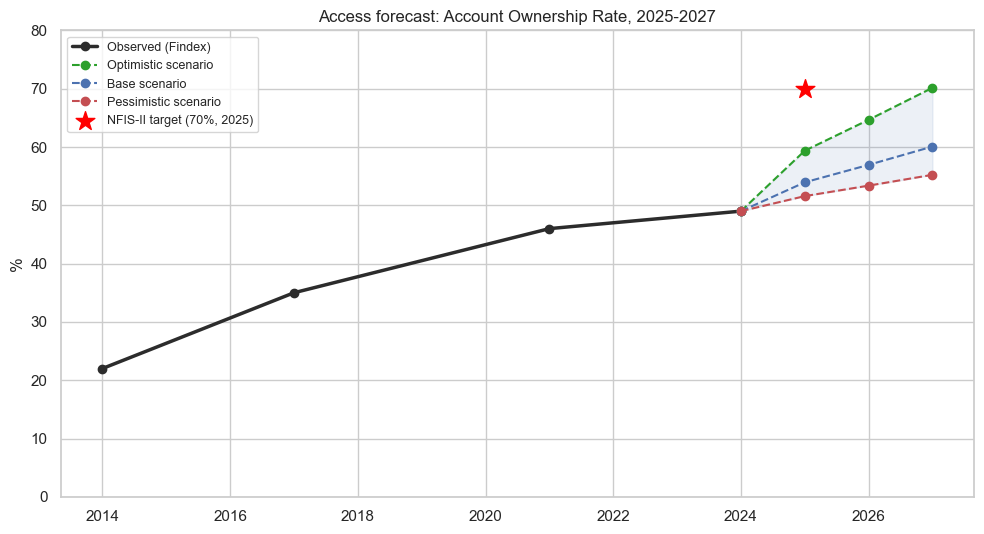

In [8]:
fig, ax = plt.subplots(figsize=(10, 5.5))

ax.plot(acc.observation_date.dt.year, acc.value_numeric, marker="o", linewidth=2.5,
        color="#2c2c2c", label="Observed (Findex)")

hist_years = [2024] + list(scenarios_acc_df.index)
for col, color in zip(["optimistic", "base", "pessimistic"], ["#2ca02c", "#4C72B0", "#C44E52"]):
    vals = [49] + list(scenarios_acc_df[col])
    ax.plot(hist_years, vals, marker="o", linestyle="--", color=color, label=f"{col.capitalize()} scenario")

ax.fill_between(hist_years, [49] + list(scenarios_acc_df.pessimistic),
                 [49] + list(scenarios_acc_df.optimistic), color="#4C72B0", alpha=0.1)

nfis = targets[targets.indicator_code == "ACC_OWNERSHIP"]
ax.scatter(nfis.observation_date.dt.year, nfis.value_numeric, color="red", marker="*",
           s=200, zorder=5, label="NFIS-II target (70%, 2025)")

ax.set_title("Access forecast: Account Ownership Rate, 2025-2027")
ax.set_ylabel("%")
ax.set_ylim(0, 80)
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "14_access_forecast_scenarios.png", dpi=150)
plt.show()

## 3. USAGE forecast: Digital Payment Adoption Rate

Only **one** Findex data point exists for this indicator (35%, 2024) —
`REC_0034`, itself an enrichment addition since it was missing from the
starter export. A trend regression is not statistically meaningful with n=1.
Instead we build transparent scenarios calibrated against the strongest
available leading indicators: P2P transaction volume (+158% YoY), the
EthioPay instant-payment launch (Dec 2025), and M-Pesa/EthSwitch
interoperability (Oct 2025) — all captured as `USG_P2P_COUNT` / usage-pillar
effects in the Task 3 model.

In [9]:
usg_start = 35.0
usg_start_year = 2024

p2p_yoy_growth = 1.58  # from REC_0016 notes
print(f"P2P transaction volume growth: +{p2p_yoy_growth*100:.0f}% YoY -- strong usage-side momentum, "
      "but Findex 'made or received a digital payment' is a broader, slower-moving composite than "
      "any single payment rail's transaction count.")

GROWTH_PP_PER_YEAR = {"optimistic": 7.0, "base": 4.0, "pessimistic": 1.5}

scenarios_usg = {"year": [2025, 2026, 2027]}
for scenario, rate in GROWTH_PP_PER_YEAR.items():
    scenarios_usg[scenario] = [min(100, usg_start + rate * (y - usg_start_year)) for y in [2025, 2026, 2027]]

scenarios_usg_df = pd.DataFrame(scenarios_usg).set_index("year")
scenarios_usg_df.round(1)

P2P transaction volume growth: +158% YoY -- strong usage-side momentum, but Findex 'made or received a digital payment' is a broader, slower-moving composite than any single payment rail's transaction count.


,optimistic,base,pessimistic
year,,,
2025,42.0,39.0,36.5
2026,49.0,43.0,38.0
2027,56.0,47.0,39.5


**Why these growth rates, and how they connect to the event model:**
- **Base (+4pp/yr):** consistent with the observed 2021→2024 Access deceleration
  *not* repeating on the Usage side, given P2P is compounding fast and EthioPay
  is a large, high-confidence-magnitude forward event in the Task 3 matrix
  (see `USG_P2P_COUNT` +30 in the association matrix). We use a smaller pp/yr
  here than the raw P2P transaction growth because Findex "made or received a
  digital payment" is a broader survey composite, not a single rail's
  transaction count, and composites move more slowly than any one channel.
- **Optimistic (+7pp/yr):** EthioPay and M-Pesa interoperability both land on
  schedule and perform like the India UPI / Tanzania interoperability
  comparables cited in Task 3's `literature`-basis impact_links.
- **Pessimistic (+1.5pp/yr):** Safaricom's Dec-2025 price increase (IMP_0022)
  and continued thin/inactive agent networks (REC_0043) drag on usage growth,
  similar in spirit to the Access-side 2021-2024 slowdown repeating on Usage.

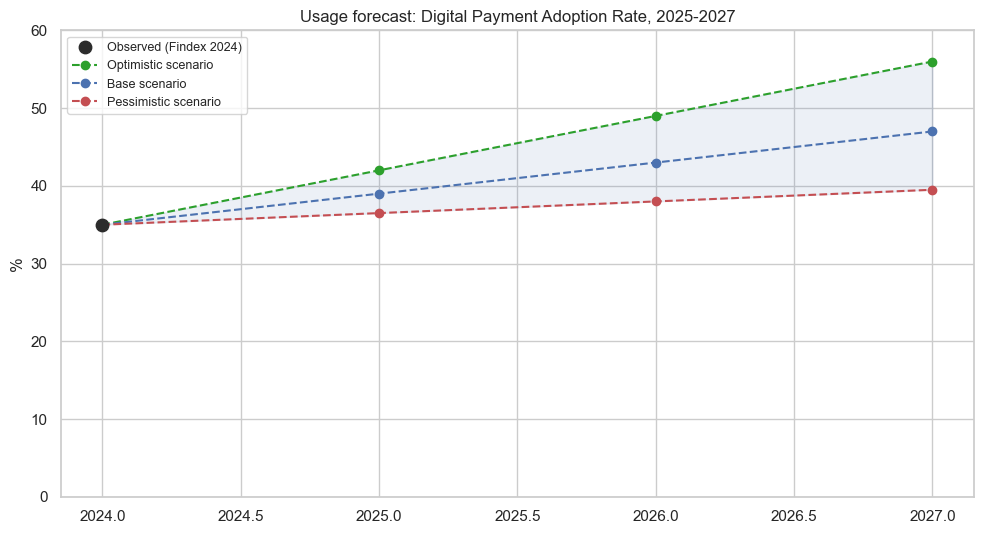

In [10]:
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.scatter([2024], [35], color="#2c2c2c", s=80, zorder=5, label="Observed (Findex 2024)")

hist_years = [2024] + list(scenarios_usg_df.index)
for col, color in zip(["optimistic", "base", "pessimistic"], ["#2ca02c", "#4C72B0", "#C44E52"]):
    vals = [35] + list(scenarios_usg_df[col])
    ax.plot(hist_years, vals, marker="o", linestyle="--", color=color, label=f"{col.capitalize()} scenario")

ax.fill_between(hist_years, [35] + list(scenarios_usg_df.pessimistic),
                 [35] + list(scenarios_usg_df.optimistic), color="#4C72B0", alpha=0.1)

ax.set_title("Usage forecast: Digital Payment Adoption Rate, 2025-2027")
ax.set_ylabel("%")
ax.set_ylim(0, 60)
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "15_usage_forecast_scenarios.png", dpi=150)
plt.show()

## 4. Combined forecast table (2025-2027)

In [11]:
forecast_table = pd.concat({
    "Access (Account Ownership %)": scenarios_acc_df,
    "Usage (Digital Payment Adoption %)": scenarios_usg_df,
}, axis=1).round(1)
forecast_table

Access (Account Ownership %)                    \
                       optimistic  base pessimistic   
year                                                  
2025                         59.4  53.9        51.6   
2026                         64.7  56.9        53.4   
2027                         70.2  60.1        55.2   

     Usage (Digital Payment Adoption %)                    
                             optimistic  base pessimistic  
year                                                       
2025                               42.0  39.0        36.5  
2026                               49.0  43.0        38.0  
2027                               56.0  47.0        39.5

In [12]:
forecast_table.to_csv(PROCESSED_DIR / "access_usage_forecast_2025_2027.csv")
print(f"Saved to {PROCESSED_DIR / 'access_usage_forecast_2025_2027.csv'}")

Saved to C:\Users\maedo\Forecasting\data\processed\access_usage_forecast_2025_2027.csv


## 5. Interpretation

**Access (Account Ownership):** our base case reaches **~60% by 2027**
(54% in 2025, 57% in 2026, 60% in 2027) — still short of the NFIS-II
70%-by-2025 target, which will clearly be missed on its original timeline.
Interestingly, our **optimistic** scenario lands almost exactly on 70% —
but not until **2027**, roughly two years behind the original NFIS-II
schedule. The pessimistic scenario (55% by 2027) shows growth barely
above the already-slow 2021-2024 pace continuing. The single largest
*positive* lever in our model is the Fayda digital ID rollout reaching
scale (reducing KYC friction for account opening) combined with the
banking mandate forcing formalization — but the banking mandate is
explicitly modeled as `mixed`-direction because it could just as easily
suppress access for adults not yet enrolled.

**Usage (Digital Payment Adoption):** we expect meaningfully faster
proportional growth than Access — base case **47% by 2027** vs. 35% in
2024 (39% in 2025, 43% in 2026, 47% in 2027), driven by EthioPay's
instant-payment rollout and M-Pesa/EthSwitch interoperability, both large
modeled effects in the Task 3 association matrix. The optimistic scenario
reaches 56% by 2027; pessimistic only 39.5%. This continues the pattern
already visible in 2024/2025 data: the P2P/ATM crossover and 158% YoY P2P
growth show Usage decoupling from and outpacing Access.

**Largest-impact events for the 2025-2027 window specifically:**
1. EthioPay Instant Payment System launch (Dec 2025) — largest modeled Usage effect.
2. Fayda digital ID reaching scale + the banking mandate — largest (and most
   uncertain — `mixed` direction) Access lever.
3. M-Pesa/EthSwitch interoperability (Oct 2025) — moderate Usage effect,
   benchmarked against Tanzania's interoperability experience.

**Key uncertainties, stated plainly:**
- Access forecast rests on an n=4 regression and a hand-built event-effect
  model layered on top of it — treat point estimates as illustrative, the
  optimistic/pessimistic spread as the more honest takeaway.
- Usage forecast has **no historical trend to anchor to at all** (n=1) — our
  scenario growth rates are judgment calls informed by P2P momentum and the
  Task 3 event matrix, not statistically estimated.
- Both forecasts assume no major negative macro shock beyond what's already
  in the event set (e.g., a further FX shock, political instability, or a
  telecom-sector disruption would invalidate the pessimistic scenario as a
  floor, not just a scenario).